In [17]:
import pandas as pd

df_train = pd.read_csv('/kaggle/input/dataset12/train.csv')
df_train.drop("id", axis=1, inplace=True)


In [18]:
import numpy as np

# Data Augmentation: Duplicate data with noise to increase training size
np.random.seed(42)
df_augmented = df_train.copy()
while len(df_augmented) < 5000:
    noise = np.random.normal(0, 0.01, size=df_train[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']].shape)
    df_noisy = df_train[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']] + noise
    df_temp = df_train.copy()
    df_temp[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']] = df_noisy
    df_augmented = pd.concat([df_augmented, df_temp], ignore_index=True)

df_augmented = df_augmented[:5000]


In [19]:


# First, install pytorch-tabnet if not

!pip install -q pytorch-tabnet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

from pytorch_tabnet.tab_model import TabNetClassifier




# Make sure df_train is already loaded and cleaned (id dropped)
import numpy as np

# Data augmentation: duplicate data with slight noise until we have 5000 rows
np.random.seed(42)
df_augmented = df_train.copy()
while len(df_augmented) < 5000:
    noise = np.random.normal(0, 0.01, size=df_train[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']].shape)
    df_noisy = df_train[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']] + noise
    df_temp = df_train.copy()
    df_temp[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']] = df_noisy
    df_augmented = pd.concat([df_augmented, df_temp], ignore_index=True)

# Truncate exactly 5000 rows
df_augmented = df_augmented[:5000]

import torch

# Load the data
df_train = pd.read_csv('/kaggle/input/dataset12/train.csv')
df_train.drop('id', axis=1, inplace=True)


# Features and target
X = df_augmented[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']]
y = df_augmented['target']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# ---------------------------
# Classical ML Models
# ---------------------------
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB()
}

classic_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    classic_results[name] = acc

print("Accuracy Before Transfer Learning:")
for name, acc in classic_results.items():
    print(f"{name}: {acc:.4f}")

# ---------------------------
# Transfer Learning with TabNet
# ---------------------------
X_train_float = X_train.astype("float32")
X_test_float = X_test.astype("float32")

clf = TabNetClassifier(verbose=0, seed=42)
clf.fit(
    X_train=X_train_float, y_train=y_train,
    eval_set=[(X_test_float, y_test)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
)

y_pred_tabnet = clf.predict(X_test_float)
tabnet_accuracy = accuracy_score(y_test, y_pred_tabnet)

print("\nAccuracy After Transfer Learning (TabNet):")
print(f"TabNet: {tabnet_accuracy:.4f}")
print("\nClassification Report (TabNet):\n")
print(classification_report(y_test, y_pred_tabnet, target_names=[str(cls) for cls in le.classes_]))


Accuracy Before Transfer Learning:
Logistic Regression: 0.7440
SVM: 0.8250
Random Forest: 0.9930
Naive Bayes: 0.7130
Stop training because you reached max_epochs = 100 with best_epoch = 92 and best_val_accuracy = 0.945


/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Accuracy After Transfer Learning (TabNet):
TabNet: 0.9450

Classification Report (TabNet):

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       564
           1       0.92      0.96      0.94       436

    accuracy                           0.94      1000
   macro avg       0.94      0.95      0.94      1000
weighted avg       0.95      0.94      0.95      1000



In [20]:

# Use the augmented dataset
X = df_augmented[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']]
y = df_augmented['target']

# Encode and scale
le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the augmented dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Convert to float for TabNet
X_train_float = X_train.astype("float32")
X_test_float = X_test.astype("float32")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 64)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 124)                 │           8,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 248)                 │          31,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 496)                 │         123,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 248)                 │         123,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 124)                 │          30,876 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │             125 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,056,805 (4.03 MB)

 Trainable params: 1,056,805 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.6235 - loss: 0.6501 - val_accuracy: 0.7530 - val_loss: 0.5305
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7584 - loss: 0.5439 - val_accuracy: 0.7940 - val_loss: 0.5089
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7737 - loss: 0.5322 - val_accuracy: 0.7940 - val_loss: 0.4884
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7866 - loss: 0.4940 - val_accuracy: 0.8220 - val_loss: 0.4627
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8081 - loss: 0.4716 - val_accuracy: 0.8240 - val_loss: 0.4283
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8191 - loss: 0.4420 - val_accuracy: 0.8570 - val_loss: 0.3871
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8241 - loss: 0.4147 - val_accuracy: 0.8380 - val_loss: 0.4068
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8339 - loss: 0.4054 - val_accuracy: 0.8730 - val_loss: 0.3571


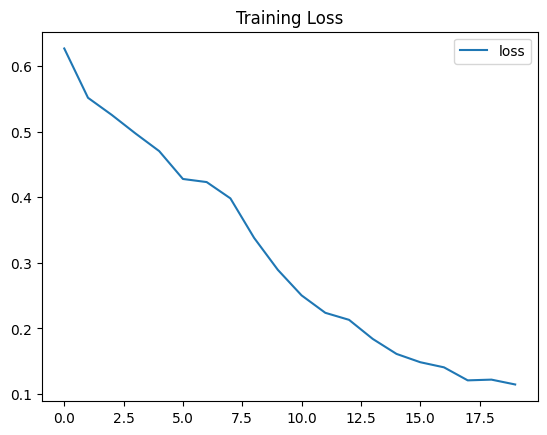

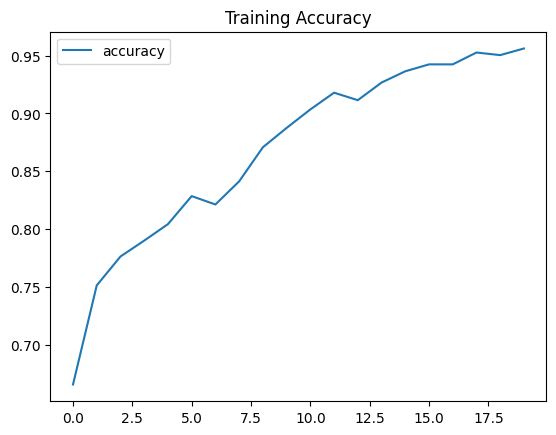

In [21]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

model = keras.Sequential([
    layers.Dense(64, input_shape=[6]),
    layers.Dense(124, activation='relu'),
    layers.Dense(248, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(248, activation='relu'),
    layers.Dense(124, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model with visible output
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=512,
    epochs=20,
    verbose=1  # Show training progress
)

# Plotting performance
performance = pd.DataFrame(history.history)
performance.loc[:, ['loss']].plot(title="Training Loss")
plt.show()
performance.loc[:, ['accuracy']].plot(title="Training Accuracy")
plt.show()

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv('/kaggle/input/dataset12/train.csv')  # Make sure this CSV is in your environment
df.drop('id', axis=1, inplace=True)

# Feature selection
X = df[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']]
y = df['target']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                     │ (None, 64)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 124)                 │           8,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 248)                 │          31,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 496)                 │         123,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 496)                 │         246,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 248)                 │         123,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 124)                 │          30,876 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 1)                   │             125 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,056,805 (4.03 MB)

 Trainable params: 1,056,805 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.5767 - loss: 0.6722 - val_accuracy: 0.7415 - val_loss: 0.6240
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7381 - loss: 0.6097 - val_accuracy: 0.7440 - val_loss: 0.5611
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7321 - loss: 0.5593 - val_accuracy: 0.7705 - val_loss: 0.5325
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7593 - loss: 0.5339 - val_accuracy: 0.7778 - val_loss: 0.5192
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7782 - loss: 0.5084 - val_accuracy: 0.8043 - val_loss: 0.4918
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7901 - loss: 0.4960 - val_accuracy: 0.7874 - val_loss: 0.4950
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8037 - loss: 0.4705 - val_accuracy: 0.7947 - val_loss: 0.4730
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8059 - loss: 0.4649 - val_accuracy: 0.8309 - val_loss: 0.4433

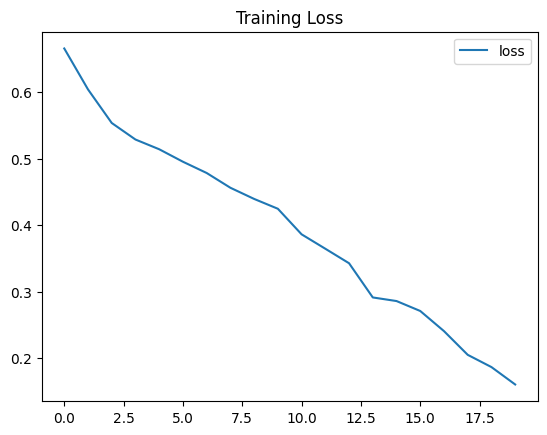

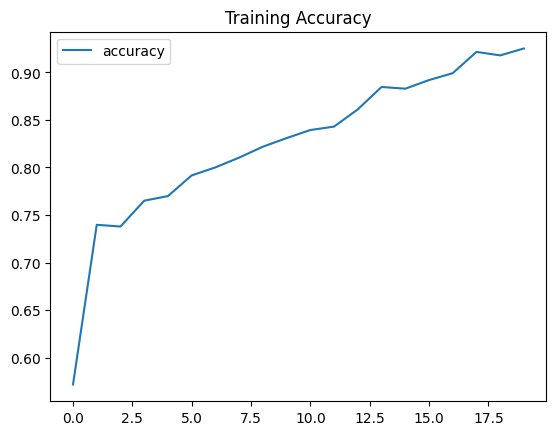

In [24]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, input_shape=[6]),
    layers.Dense(124, activation='relu'),
    layers.Dense(248, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(496, activation='relu'),
    layers.Dense(248, activation='relu'),
    layers.Dense(124, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=512,
    epochs=20,
    verbose=1  # Show output
)

# Plot training performance
performance = pd.DataFrame(history.history)
performance.loc[:, ['loss']].plot(title="Training Loss")
plt.show()
performance.loc[:, ['accuracy']].plot(title="Training Accuracy")
plt.show()


Stop training because you reached max_epochs = 20 with best_epoch = 19 and best_val_accuracy = 0.848


/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


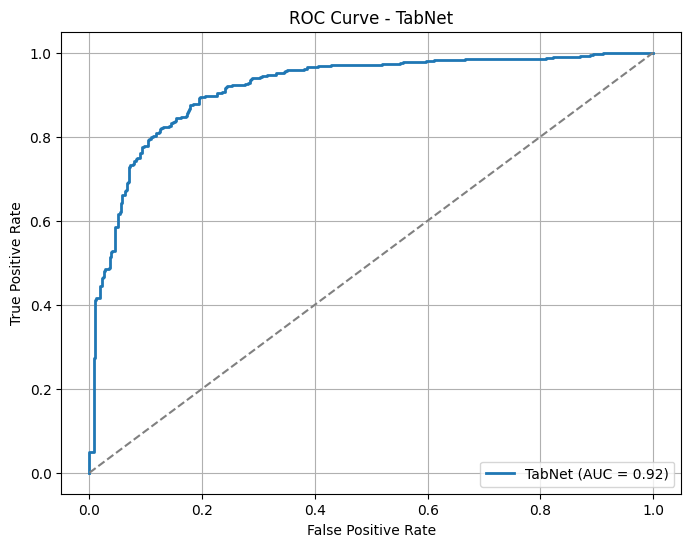

In [27]:

# Use the augmented dataset for TabNet
X_tabnet = df_augmented[['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']]
y_tabnet = df_augmented['target']

# Encode and scale
le = LabelEncoder()
y_encoded_tabnet = le.fit_transform(y_tabnet)
scaler = StandardScaler()
X_scaled_tabnet = scaler.fit_transform(X_tabnet)

# Split for TabNet (make sure y_test and X_test_float align in length)
X_train_tabnet, X_test_tabnet, y_train_tabnet, y_test_tabnet = train_test_split(
    X_scaled_tabnet, y_encoded_tabnet, test_size=0.2, random_state=42
)

X_train_float = X_train_tabnet.astype("float32")
X_test_float = X_test_tabnet.astype("float32")

# Train TabNet
clf.fit(
    X_train=X_train_float, y_train=y_train_tabnet,
    eval_set=[(X_test_float, y_test_tabnet)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=20,  # keep short for testing
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
)

# Predict and plot ROC curve
y_proba_tabnet = clf.predict_proba(X_test_float)[:, 1]
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_tabnet, y_proba_tabnet)
roc_auc_tabnet = auc(fpr_tabnet, tpr_tabnet)


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# TabNet predictions (assumes y_proba_tabnet and y_test_tabnet are defined)
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_tabnet, y_proba_tabnet)
roc_auc_tabnet = auc(fpr_tabnet, tpr_tabnet)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_tabnet, tpr_tabnet, label=f'TabNet (AUC = {roc_auc_tabnet:.2f})', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TabNet')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()  # <-- This is crucial
